In [9]:
# Initial EDA: Brent Oil Prices & Geopolitical Events

## Plan
- Load Brent oil price and event data
- Visualize price trends and annotate major events
- Explore summary statistics and missing values
- Identify potential change points visually

## Key Findings (to be updated)
- Data loaded and cleaned
- Major events annotated on price timeline
- Initial change point candidates identified
- See plots and code below for details



SyntaxError: invalid syntax (274316714.py, line 4)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
oil_df = pd.read_csv('../data/BrentOilPrices.csv')
events_df = pd.read_csv('../data/geopolitical_events.csv')


oil_df.head(), events_df.head()


(        Date  Price
 0  20-May-87  18.63
 1  21-May-87  18.45
 2  22-May-87  18.55
 3  25-May-87  18.60
 4  26-May-87  18.63,
          date                               event          type  impact
 0  2011-01-25         Arab Spring begins in Egypt  Geopolitical    High
 1  2014-06-10                 ISIS captures Mosul  Geopolitical    High
 2  2014-11-27  OPEC refuses to cut oil production          OPEC    High
 3  2016-01-16           Lifting of Iran sanctions  Geopolitical  Medium
 4  2016-11-30       OPEC agrees to cut production          OPEC    High)

In [14]:
# Check for missing values and show summary statistics
oil_df.info()
print(oil_df.describe())
print(events_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   object 
 1   Price   9011 non-null   float64
dtypes: float64(1), object(1)
memory usage: 140.9+ KB
             Price
count  9011.000000
mean     48.420782
std      32.860110
min       9.100000
25%      19.050000
50%      38.570000
75%      70.090000
max     143.950000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    15 non-null     object
 1   event   15 non-null     object
 2   type    15 non-null     object
 3   impact  15 non-null     object
dtypes: object(4)
memory usage: 608.0+ bytes
None


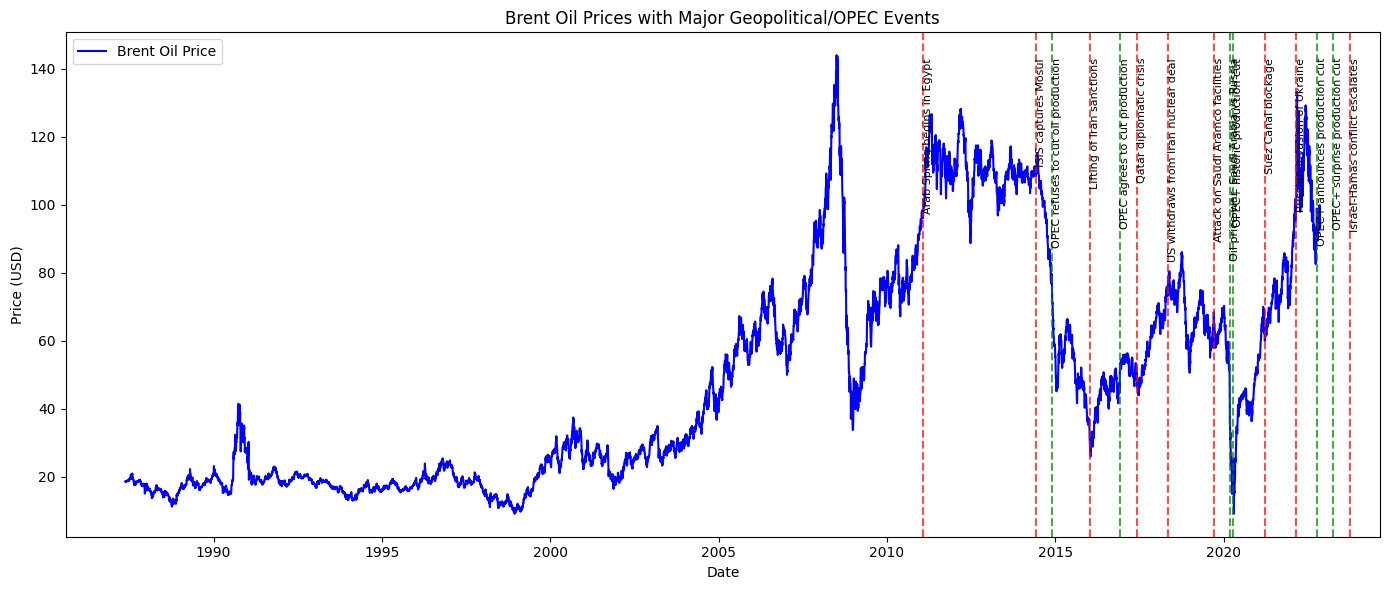

In [17]:
import matplotlib.dates as mdates

# Ensure date columns are datetime
oil_df['Date'] = pd.to_datetime(oil_df['Date'])
events_df['date'] = pd.to_datetime(events_df['date'])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(oil_df['Date'], oil_df['Price'], label='Brent Oil Price', color='blue')

# Annotate events
for _, row in events_df.iterrows():
    ax.axvline(row['date'], color='red' if row['type'] == 'Geopolitical' else 'green', linestyle='--', alpha=0.7)
    ax.text(row['date'], ax.get_ylim()[1]*0.95, row['event'], rotation=90, verticalalignment='top', fontsize=8)

ax.set_title('Brent Oil Prices with Major Geopolitical/OPEC Events')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()